# Step 05B: Ebola — Sitewise Mutation & Constraint Analysis

This notebook mirrors **05A (Lassa)** but for **Ebola**.

It uses the Step 04B outputs to:
- Characterize **sitewise conservation and mutation hotspots** in Ebola
- Identify **critical / conserved regions** vs **hotspots**
- Rank **dangerous vs harmless substitutions** (impact scores)
- Select **lab validation candidates** (rare + high-impact in conserved sites)
- Analyze **ESM outlier sequences** (unusual / adaptive variants)
- Provide helper functions to **answer mutation questions** clearly per site and substitution

Outputs are written to `results/ebola/05b/` for later comparison in 05C.


In [8]:
# 0. Imports & Paths (RUN FIRST)

import os
import math
import time
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from Bio import SeqIO
import torch

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

# Assume this notebook is at notebooks/Steps_Notebook
REPO_ROOT = Path("/Users/user/data")
print("Repo root   :", REPO_ROOT.resolve())

# --- INPUTS from Step 04B (Ebola) ---
# Adjust names if your Step 04B saved them differently
EBOLA_SITE_CSV = REPO_ROOT / "results" / "ebola_step04A" / "Ebolaa_site_scores_reference_based.csv"  
EBOLA_MUT_CSV  = REPO_ROOT / "results" / "ebola_step04A" / "Ebola_mutation_scores_reference_based.csv" 
EBOLA_ESM_CSV  = REPO_ROOT / "results" / "ebola_step04A" / "Ebola_esm_outlier_report.csv"

# Optional (if you want direct embedding-based NN analysis)
EBOLA_EMB_PT   = REPO_ROOT / "data" / "embeddings" / "ebola_embeddings.pt" 
EBOLA_META_CSV = REPO_ROOT / "data" / "embeddings" / "ebola_metadata.csv"

print("Site table :", EBOLA_SITE_CSV, "exists:", EBOLA_SITE_CSV.exists())
print("Mut table  :", EBOLA_MUT_CSV,  "exists:", EBOLA_MUT_CSV.exists())
print("ESM report :", EBOLA_ESM_CSV,  "exists:", EBOLA_ESM_CSV.exists())

# --- OUTPUTS for 05B ---
OUT_DIR = REPO_ROOT / "results" / "ebola_step05A" 
FIG_DIR = OUT_DIR / "figures"
TBL_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved under:", OUT_DIR.resolve())




Repo root   : /Users/user/data
Site table : /Users/user/data/results/ebola_step04A/Ebolaa_site_scores_reference_based.csv exists: True
Mut table  : /Users/user/data/results/ebola_step04A/Ebola_mutation_scores_reference_based.csv exists: True
ESM report : /Users/user/data/results/ebola_step04A/Ebola_esm_outlier_report.csv exists: True
Outputs will be saved under: /Users/user/data/results/ebola_step05A


In [9]:
# 1. Load Ebola Step 04B results

if not EBOLA_SITE_CSV.exists():
    raise FileNotFoundError(f"Missing Ebola site table (Step 04B): {EBOLA_SITE_CSV}")
if not EBOLA_MUT_CSV.exists():
    raise FileNotFoundError(f"Missing Ebola mutation table (Step 04B): {EBOLA_MUT_CSV}")
if not EBOLA_ESM_CSV.exists():
    raise FileNotFoundError(f"Missing Ebola ESM outlier report (Step 04B): {EBOLA_ESM_CSV}")

site = pd.read_csv(EBOLA_SITE_CSV)
mut  = pd.read_csv(EBOLA_MUT_CSV)
esm  = pd.read_csv(EBOLA_ESM_CSV)

print("site:", site.shape)
print("mut :", mut.shape)
print("esm :", esm.shape)

display(site.head())
display(mut.head())
display(esm.head())

# Optional: load embeddings (for deeper NN/cluster analysis)
if EBOLA_EMB_PT.exists() and EBOLA_META_CSV.exists():
    emb = torch.load(EBOLA_EMB_PT, map_location="cpu")
    emb_meta = pd.read_csv(EBOLA_META_CSV)
    print("Embeddings:", type(emb), getattr(emb, "shape", None))
    print("Emb meta  :", emb_meta.shape)
else:
    emb = None
    emb_meta = None
    print("No embedding .pt or metadata CSV found for Ebola; ESM analysis limited to esm CSV.")


site: (676, 9)
mut : (12844, 10)
esm : (1610, 8)


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category
0,1,M,M,0.003727,1604,1.0,0.0,M:1604,Critical
1,2,G,G,0.004969,1602,1.0,0.0,G:1602,Critical
2,3,V,V,0.003727,1604,1.0,0.0,V:1604,Critical
3,4,T,T,0.003727,1604,1.0,0.0,T:1604,Critical
4,5,G,G,0.003727,1604,1.0,0.0,G:1604,Critical


,ref_pos,ref_aa,alt_aa,alt_freq_in_dataset,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category
0,1,M,A,0.0,-1,1.0,0.0,Critical,88.749985,Critical
1,1,M,C,0.0,-1,1.0,0.0,Critical,88.749985,Critical
2,1,M,D,0.0,-3,1.0,0.0,Critical,96.249985,Critical
3,1,M,E,0.0,-2,1.0,0.0,Critical,92.499985,Critical
4,1,M,F,0.0,0,1.0,0.0,Critical,84.999985,Critical


,id,sequence,length,virus,embedding_idx,cos_dist_to_centroid,esm_outlier_score,esm_outlier_category
0,EBOV|PL6070|KU296614|SLE|Kambia|2015-04-11,TPRGLETQQPSLGNIRNSLKTNCSESQNSEYGFSSSESLDDAESHI...,5769,Ebola,1572,0.000861,100.0,Critical
1,EBOV|PL5428|KU296532|SLE|Kambia|2015-03-27,TPRGLETQQPSLGNIRNSLKTNCSESQNSEYGFSSSESLDDAESHI...,5832,Ebola,1564,0.000926,100.0,Critical
2,EBOV|PL9199|KU296371|SLE|PortLoko|2015-07-13,TPRGLETQQPSLGNIRNSLKTNCSESQNSEYGFSSSESLDDAESHI...,5833,Ebola,1609,0.000905,100.0,Critical
3,EBOV|G5364.1|KR105305|SLE|_|2014-08-28,KKKEEFLGSFVCELGRLIIFLIEIYINLNNCYCNHTWFFRAISPRR...,5866,Ebola,1084,0.000342,100.0,Critical
4,EBOV|G5529.1|KR105309|SLE|Kono|2014-09-05,NLNNCYCNHTWFFRAISPRRTTVSGGGKGISVLSKSLVNIALSHHK...,5749,Ebola,1088,0.000413,100.0,Critical


No embedding .pt or metadata CSV found for Ebola; ESM analysis limited to esm CSV.


## 2. Global site behavior — categories, conservation, entropy

This section answers:
- How many sites are **Critical / Conserved / Hotspot / Intermediate** in Ebola?
- Where (along the reference) are the **most conserved** vs **most variable** positions?

In [10]:
# 2.1 Category distribution
cat_counts = site["site_category"].value_counts().reset_index()
cat_counts.columns = ["site_category", "count"]
cat_counts["fraction"] = cat_counts["count"] / cat_counts["count"].sum()
display(cat_counts)

cat_counts.to_csv(TBL_DIR / "ebola_site_category_summary.csv", index=False)

if "ref_pos" in site.columns:
    print("Max ref_pos:", site["ref_pos"].max())
else:
    print("WARNING: site table missing ref_pos column")


,site_category,count,fraction
0,Critical,669,0.989645
1,Conserved,6,0.008876
2,MostlyGap,1,0.001479


Max ref_pos: 676


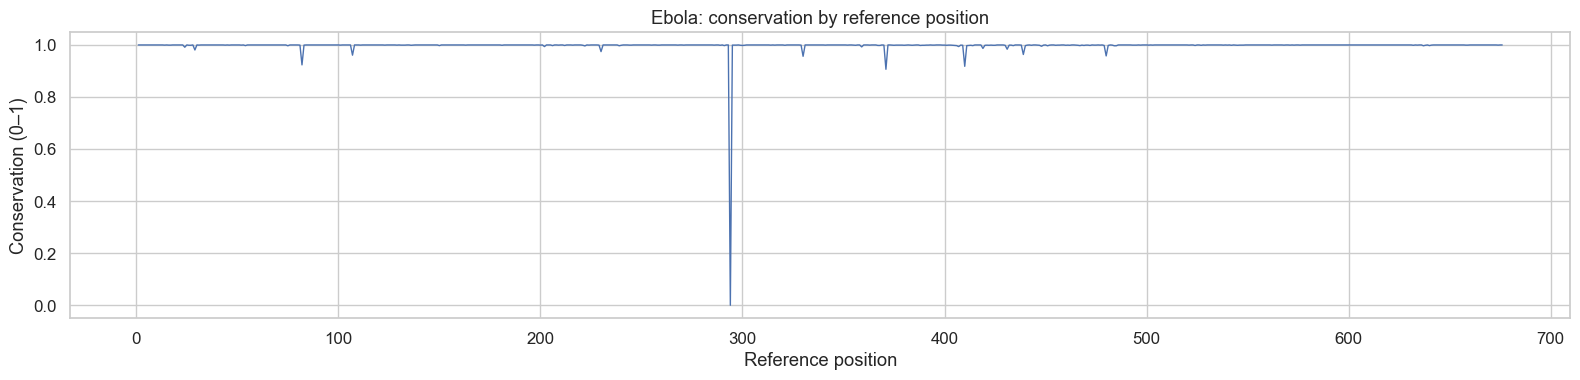

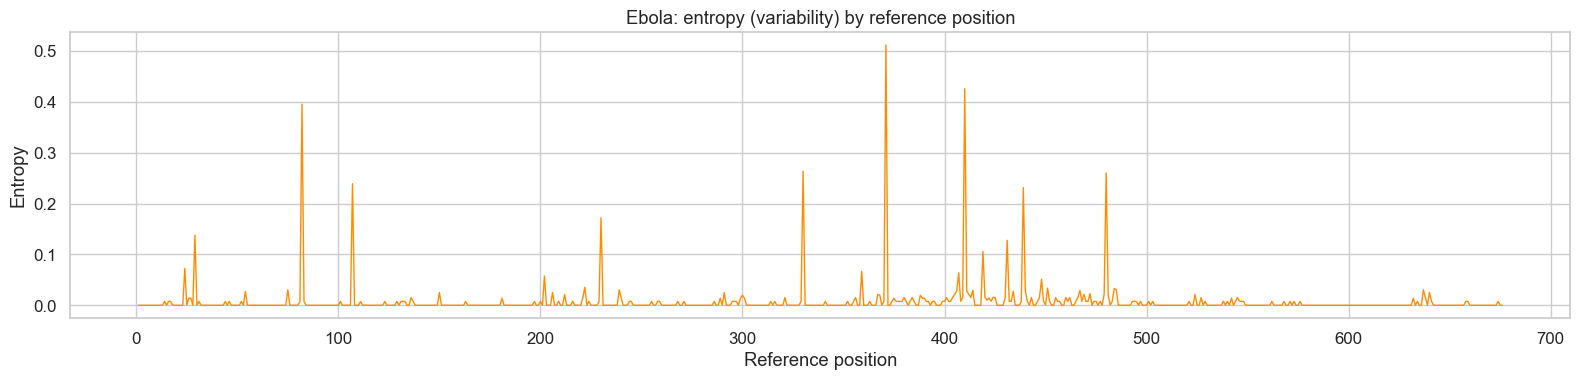

In [11]:
# 2.2 Conservation and entropy curves

plt.figure(figsize=(16,4))
plt.plot(site["ref_pos"], site["conservation"], linewidth=1)
plt.xlabel("Reference position")
plt.ylabel("Conservation (0–1)")
plt.title("Ebola: conservation by reference position")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_conservation_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(16,4))
plt.plot(site["ref_pos"], site["entropy"], linewidth=1, color="darkorange")
plt.xlabel("Reference position")
plt.ylabel("Entropy")
plt.title("Ebola: entropy (variability) by reference position")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_entropy_curve.png", dpi=300)
plt.show()


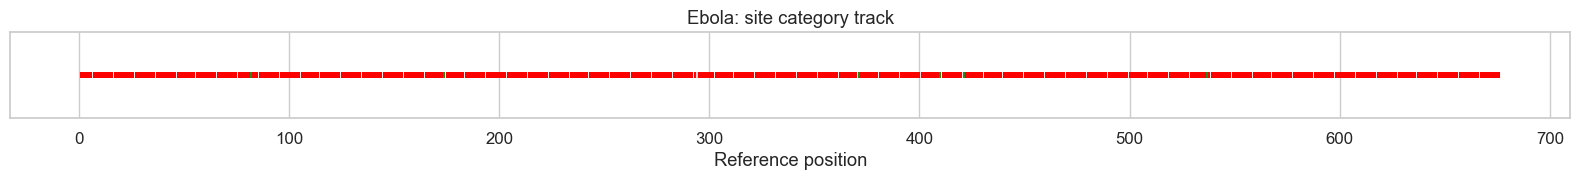

In [12]:
# 2.3 Category barcode track

plt.figure(figsize=(16,2))
color_map = dict(
    Critical="red",
    Conserved="forestgreen",
    Hotspot="gold",
    Intermediate="gray",
    MostlyGap="lightgray",
)
colors = [color_map.get(c, "black") for c in site["site_category"]]
plt.scatter(site["ref_pos"], [1]*len(site), c=colors, marker="|", s=20)
plt.yticks([])
plt.xlabel("Reference position")
plt.title("Ebola: site category track")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_site_category_barcode.png", dpi=300)
plt.show()


## 3. Hotspots and critical sites

This section finds:
- **Hotspots**: high-entropy "Hotspot" sites (most variable)
- **Critical**: highly conserved sites that likely cannot tolerate mutation

In [13]:
# 3.1 Hotspots and critical sites tables

hotspots = site[site["site_category"] == "Hotspot"].sort_values("entropy", ascending=False)
critical = site[site["site_category"] == "Critical"].sort_values("conservation", ascending=False)

hotspots.head(200).to_csv(TBL_DIR / "ebola_top_hotspots.csv", index=False)
critical.head(200).to_csv(TBL_DIR / "ebola_top_critical_sites.csv", index=False)

print("Hotspots:", hotspots.shape[0])
print("Critical:", critical.shape[0])

display(hotspots.head(10))
display(critical.head(10))


Hotspots: 0
Critical: 669


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category
0,1,M,M,0.003727,1604,1.0,0.0,M:1604,Critical
414,415,S,S,0.022360,1574,1.0,0.0,S:1574,Critical
449,450,T,T,0.013043,1589,1.0,0.0,T:1589,Critical
444,445,D,D,0.013665,1588,1.0,0.0,D:1588,Critical
443,444,L,L,0.013665,1588,1.0,0.0,L:1588,Critical
441,442,D,D,0.014907,1586,1.0,0.0,D:1586,Critical
436,437,T,T,0.017391,1582,1.0,0.0,T:1582,Critical
435,436,N,N,0.017391,1582,1.0,0.0,N:1582,Critical
434,435,T,T,0.018012,1581,1.0,0.0,T:1581,Critical
428,429,P,P,0.024845,1570,1.0,0.0,P:1570,Critical


## 4. Substitution-level risk: dangerous vs harmless mutations

Here we analyze the substitution scores from Step 04B:
- Global distribution of **impact_score**
- Top dangerous and top harmless substitutions
- Basis for lab validation and future model explanations (Step 06).

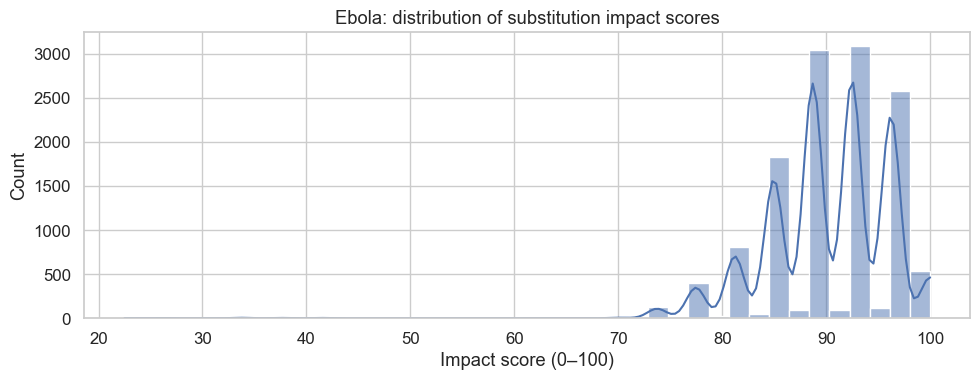

,ref_pos,ref_aa,alt_aa,alt_freq_in_dataset,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category
3646,192,D,W,0.0,-4,1.0,0.0,Critical,99.999985,Critical
2402,127,D,L,0.0,-4,1.0,0.0,Critical,99.999985,Critical
2262,120,E,C,0.0,-4,1.0,0.0,Critical,99.999985,Critical
2282,121,C,E,0.0,-4,1.0,0.0,Critical,99.999985,Critical
2301,122,L,D,0.0,-4,1.0,0.0,Critical,99.999985,Critical
11402,601,C,E,0.0,-4,1.0,0.0,Critical,99.999985,Critical
2304,122,L,G,0.0,-4,1.0,0.0,Critical,99.999985,Critical
12640,666,I,G,0.0,-4,1.0,0.0,Critical,99.999985,Critical
11370,599,G,L,0.0,-4,1.0,0.0,Critical,99.999985,Critical
11368,599,G,I,0.0,-4,1.0,0.0,Critical,99.999985,Critical


,ref_pos,ref_aa,alt_aa,alt_freq_in_dataset,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category
5580,294,K,R,0.0,2,0.0,0.0,MostlyGap,22.499985,Neutral
5579,294,K,Q,0.0,1,0.0,0.0,MostlyGap,26.249985,Neutral
5570,294,K,E,0.0,1,0.0,0.0,MostlyGap,26.249985,Neutral
5581,294,K,S,0.0,0,0.0,0.0,MostlyGap,29.999985,Neutral
5577,294,K,N,0.0,0,0.0,0.0,MostlyGap,29.999985,Neutral
5576,294,K,M,0.0,-1,0.0,0.0,MostlyGap,33.749985,Neutral
5582,294,K,T,0.0,-1,0.0,0.0,MostlyGap,33.749985,Neutral
5578,294,K,P,0.0,-1,0.0,0.0,MostlyGap,33.749985,Neutral
5567,294,K,A,0.0,-1,0.0,0.0,MostlyGap,33.749985,Neutral
5573,294,K,H,0.0,-1,0.0,0.0,MostlyGap,33.749985,Neutral


In [14]:
# 4.1 Distribution of impact scores

plt.figure(figsize=(10,4))
sns.histplot(mut["impact_score"], bins=40, kde=True)
plt.xlabel("Impact score (0–100)")
plt.title("Ebola: distribution of substitution impact scores")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_mutation_impact_distribution.png", dpi=300)
plt.show()

# 4.2 Top dangerous vs harmless substitutions

top_danger = mut.sort_values("impact_score", ascending=False)
top_harmless = mut.sort_values("impact_score", ascending=True)

top_danger.head(500).to_csv(TBL_DIR / "ebola_top_dangerous_mutations.csv", index=False)
top_harmless.head(500).to_csv(TBL_DIR / "ebola_top_harmless_mutations.csv", index=False)

display(top_danger.head(10))
display(top_harmless.head(10))


## 5. Lab validation candidates

High-priority candidates are:
- At **Critical/Conserved** sites
- Have **rare** alt amino acid (low frequency in dataset)
- Have **high impact_score**

In [15]:
# 5.1 Rare + high-impact at conserved/critical sites

lab = mut[
    (mut["site_category"].isin(["Critical", "Conserved"])) &
    (mut["alt_freq_in_dataset"] <= 0.001) &
    (mut["impact_score"] >= 80)
].sort_values(["impact_score", "site_conservation"], ascending=[False, False])

lab.head(500).to_csv(TBL_DIR / "ebola_lab_validation_candidates.csv", index=False)
print("Lab candidates:", lab.shape[0])
display(lab.head(15))


Lab candidates: 12218


,ref_pos,ref_aa,alt_aa,alt_freq_in_dataset,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category
25,2,G,I,0.0,-4,1.0,0.0,Critical,99.999985,Critical
27,2,G,L,0.0,-4,1.0,0.0,Critical,99.999985,Critical
82,5,G,I,0.0,-4,1.0,0.0,Critical,99.999985,Critical
84,5,G,L,0.0,-4,1.0,0.0,Critical,99.999985,Critical
100,6,I,G,0.0,-4,1.0,0.0,Critical,99.999985,Critical
116,7,L,D,0.0,-4,1.0,0.0,Critical,99.999985,Critical
119,7,L,G,0.0,-4,1.0,0.0,Critical,99.999985,Critical
154,9,L,D,0.0,-4,1.0,0.0,Critical,99.999985,Critical
157,9,L,G,0.0,-4,1.0,0.0,Critical,99.999985,Critical
175,10,P,F,0.0,-4,1.0,0.0,Critical,99.999985,Critical


## 6. ESM outliers: unusual Ebola sequences

This section uses the Step 04B ESM outlier report to find:
- Top outlier sequences (unusual embeddings)
- Distribution of outlier scores
- Optionally, relation with sequence length (QC / adaptation hints).

,id,sequence,length,virus,embedding_idx,cos_dist_to_centroid,esm_outlier_score,esm_outlier_category
0,EBOV|PL6070|KU296614|SLE|Kambia|2015-04-11,TPRGLETQQPSLGNIRNSLKTNCSESQNSEYGFSSSESLDDAESHI...,5769,Ebola,1572,0.000861,100.0,Critical
55,EBOV|EM_COY_2015_016263||GIN|Forecariah|2015-0...,LGRLIILLIEIYINLSNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5395,Ebola,174,0.000331,100.0,Critical
63,EBOV|GUI_CTS_2015_0051||GIN|Boke|2015-06-21,LGRLIILLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5060,Ebola,231,0.000470,100.0,Critical
62,EBOV|CON-8559||GIN|Conakry|2015-06-21,LGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5559,Ebola,144,0.000371,100.0,Critical
61,EBOV|EM_COY_2015_016414||GIN|Dubreka|2015-05-11,LGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5397,Ebola,178,0.000361,100.0,Critical
60,EBOV|EM_COY_2015_013731||GIN|Coyah|2015-03-14,LGRLIILLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5137,Ebola,156,0.000683,100.0,Critical
59,EBOV|EM_COY_2015_013962||GIN|Forecariah|2015-0...,LGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,5560,Ebola,159,0.000353,100.0,Critical
58,EBOV|EM_COY_2015_013795||GIN|Forecariah|2015-0...,LGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,4940,Ebola,157,0.000346,100.0,Critical
57,EBOV|EM_COY_2015_023888||GIN|Dubreka|2015-09-15,LGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGISVL...,4625,Ebola,138,0.000337,100.0,Critical
56,EBOV|DML25123|KT357854|SLE|Kenema|2015-02-18,SGGGKGISVLSKSLVNIALSHHKFRLKLCRVIQQPQHYCRTALVHS...,5741,Ebola,134,0.000661,100.0,Critical


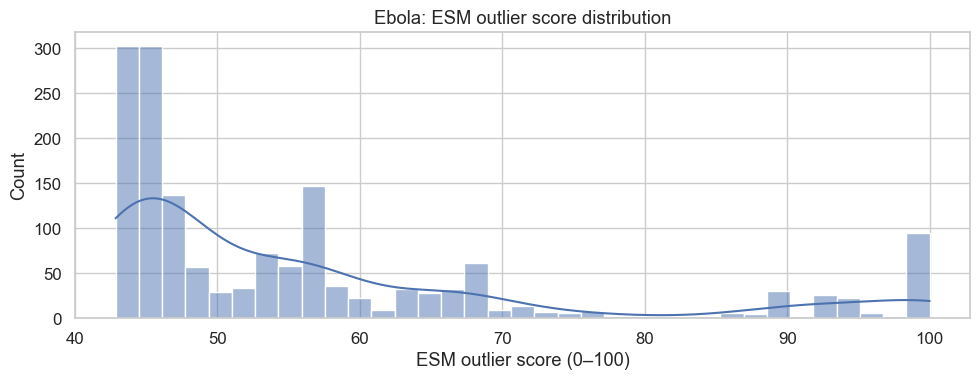

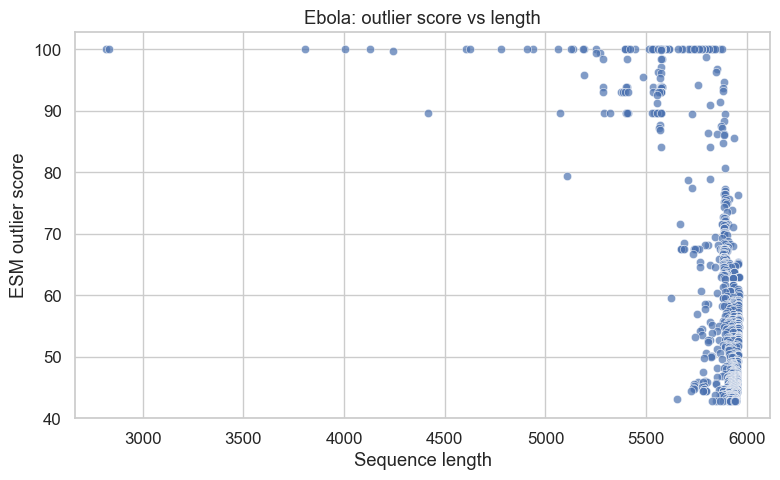

In [16]:
# 6.1 Top outlier sequences

assert "esm_outlier_score" in esm.columns, "ESM outlier score column missing in Ebola ESM CSV."

outliers = esm.sort_values("esm_outlier_score", ascending=False)
outliers.head(200).to_csv(TBL_DIR / "ebola_outlier_sequences.csv", index=False)
display(outliers.head(10))

# 6.2 Outlier distribution

plt.figure(figsize=(10,4))
sns.histplot(esm["esm_outlier_score"], bins=35, kde=True)
plt.xlabel("ESM outlier score (0–100)")
plt.title("Ebola: ESM outlier score distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_outlier_score_distribution.png", dpi=300)
plt.show()

# 6.3 Outlier vs length (if length column exists)

if "length" in esm.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=esm["length"], y=esm["esm_outlier_score"], alpha=0.7)
    plt.xlabel("Sequence length")
    plt.ylabel("ESM outlier score")
    plt.title("Ebola: outlier score vs length")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ebola_outlier_vs_length.png", dpi=300)
    plt.show()
else:
    print("No 'length' column in Ebola ESM CSV; skipping outlier vs length plot.")


## 7. Helper to answer mutation questions at a site

This function lets you query: given `(ref_pos, ref_aa, alt_aa)`, return the full record from `ebola_mutation_scores_reference_based.csv`.

This is the key building block for Step 06, where a user inputs mutations and the model explains: 
- which site,
- what category (Critical / Hotspot),
- how risky (impact_score, impact_category),
- and how common that alt amino acid is.

In [18]:
def query_ebola_mutation(ref_pos: int, ref_aa: str, alt_aa: str):
    q = mut[
        (mut["ref_pos"] == ref_pos) &
        (mut["ref_aa"] == ref_aa) &
        (mut["alt_aa"] == alt_aa)
    ]
    if q.empty:
        return None
    return q.iloc[0].to_dict()

# Example (adjust to a real position and AAs from your dataset):
# example = query_ebola_mutation(123, "A", "D")
# example


### Optional: score a list of user mutations for Ebola

This small helper is for Step 06; here we just provide it to keep 05B complete.

Given a list like `[{"pos": 123, "ref": "A", "alt": "D"}, ...]` it looks up each in the Ebola mutation table and returns a DataFrame with impact and category if available.

In [19]:
def score_ebola_mutation_list(mutation_list):
    rows = []
    for m in mutation_list:
        pos = m["pos"]
        ref = m["ref"]
        alt = m["alt"]
        rec = query_ebola_mutation(pos, ref, alt)
        if rec is None:
            rows.append({**m, "impact_score": None, "impact_category": None, "note": "not found in table"})
        else:
            rows.append({**m, **rec})
    return pd.DataFrame(rows)

# Example usage (uncomment when you have real positions):
# user_muts = [
#     {"pos": 123, "ref": "A", "alt": "D"},
#     {"pos": 456, "ref": "G", "alt": "V"},
# ]
# score_ebola_mutation_list(user_muts)


## 8. (Optional) Embedding-based nearest neighbors (if raw embeddings loaded)

If you loaded `ebola_embeddings.pt` and `ebola_metadata.csv`, you can:
- compute centroid-based outlier scores (independent sanity check),
- get nearest neighbors for a given Ebola sequence in embedding space.

This is not required for 05B, but useful for deeper sequence-level insight or QC.

In [20]:
def cosine_distance_to_centroid(X: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    Xn = X / (torch.linalg.norm(X, dim=1, keepdim=True) + eps)
    c = Xn.mean(dim=0)
    sim = Xn @ c
    return 1.0 - sim

if emb is not None and emb_meta is not None and isinstance(emb, torch.Tensor):
    X = emb.float()
    d = cosine_distance_to_centroid(X)
    # simple robust z-score
    med = d.median()
    mad = (d - med).abs().median()
    z = (d - med) / (1.4826 * mad + 1e-12)
    # map to 0–100
    zc = torch.clamp(z, -6, 6)
    score = (zc + 6) * (100.0 / 12.0)
    emb_meta["esm_outlier_from_embedding"] = score.tolist()
    emb_meta.sort_values("esm_outlier_from_embedding", ascending=False).head(100).to_csv(
        TBL_DIR / "ebola_embedding_based_top_outliers.csv", index=False
    )
    print("Saved embedding-based top outliers to:", TBL_DIR / "ebola_embedding_based_top_outliers.csv")
else:
    print("Embedding tensors/metadata not available or invalid, skipping deeper NN/outlier analysis.")


Embedding tensors/metadata not available or invalid, skipping deeper NN/outlier analysis.


## 9. Summary of outputs

This cell prints the main tables and figures generated in 05B.

In [21]:
print("05B Ebola analysis complete.")
print("Tables saved in:", TBL_DIR)
print("Figures saved in:", FIG_DIR)

print("\nTables:")
for p in sorted(TBL_DIR.glob("*.csv")):
    print(" -", p.name)

print("\nFigures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)


05B Ebola analysis complete.
Tables saved in: /Users/user/data/results/ebola_step05A/tables
Figures saved in: /Users/user/data/results/ebola_step05A/figures

Tables:
 - ebola_lab_validation_candidates.csv
 - ebola_outlier_sequences.csv
 - ebola_site_category_summary.csv
 - ebola_top_critical_sites.csv
 - ebola_top_dangerous_mutations.csv
 - ebola_top_harmless_mutations.csv
 - ebola_top_hotspots.csv

Figures:
 - ebola_conservation_curve.png
 - ebola_entropy_curve.png
 - ebola_mutation_impact_distribution.png
 - ebola_outlier_score_distribution.png
 - ebola_outlier_vs_length.png
 - ebola_site_category_barcode.png
